# Heart Disease Prediction using Machine Learning

## Objective
To build a classification model that predicts whether a person has heart disease based on medical attributes using machine learning techniques.


In [1]:
# Cell 1 – Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Cell 2 – Load the Dataset

df = pd.read_csv("Heart.csv")

# Drop the unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (303, 14)

First 5 Rows:


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [3]:
# Cell 3 – Dataset Overview

print("=== Column Info ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Column Info ===
Age            int64
Sex            int64
ChestPain        str
RestBP         int64
Chol           int64
Fbs            int64
RestECG        int64
MaxHR          int64
ExAng          int64
Oldpeak      float64
Slope          int64
Ca           float64
Thal             str
AHD              str
dtype: object

=== Missing Values ===
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
dtype: int64

=== Basic Statistics ===


,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [4]:
# Cell 4 – Handle Missing Values

# Fill missing values with mode (most frequent value)
df['Ca'].fillna(df['Ca'].mode()[0], inplace=True)
df['Thal'].fillna(df['Thal'].mode()[0], inplace=True)

print("✅ Missing values handled.")
print(df.isnull().sum())

✅ Missing values handled.
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
dtype: int64


In [5]:
# Cell 5 – Encode Categorical Columns

le = LabelEncoder()

categorical_cols = ['ChestPain', 'Thal', 'AHD']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical columns encoded.")
print(df[categorical_cols].head())

✅ Categorical columns encoded.
   ChestPain  Thal  AHD
0          3     0    0
1          0     1    1
2          0     2    1
3          1     1    0
4          2     1    0


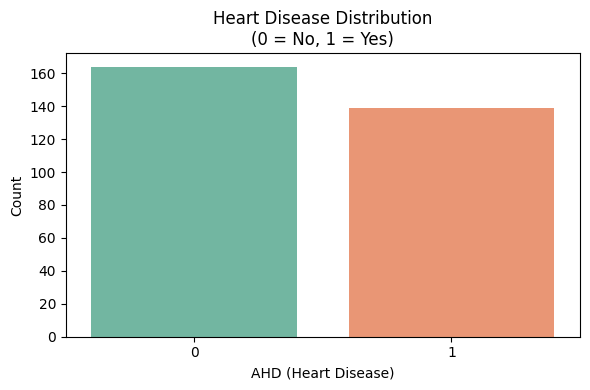

Target distribution:
AHD
0    164
1    139
Name: count, dtype: int64


In [6]:
# Cell 6 – EDA: Target Distribution

plt.figure(figsize=(6, 4))
sns.countplot(x='AHD', data=df, palette='Set2')
plt.title('Heart Disease Distribution\n(0 = No, 1 = Yes)')
plt.xlabel('AHD (Heart Disease)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Target distribution:")
print(df['AHD'].value_counts())

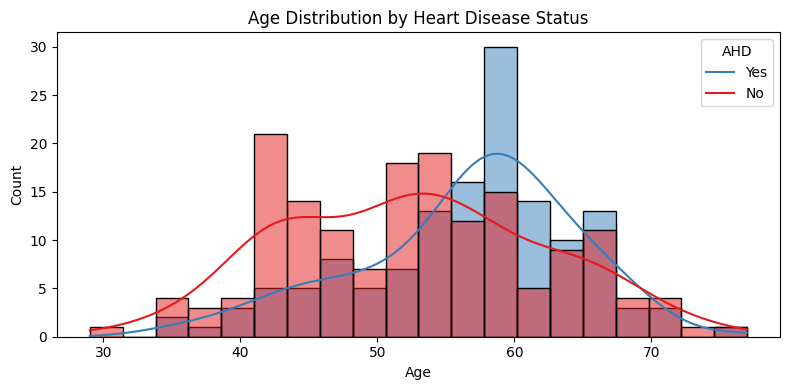

In [7]:
# Cell 7 – EDA: Age Distribution by Target

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='AHD', kde=True, palette='Set1', bins=20)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='AHD', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

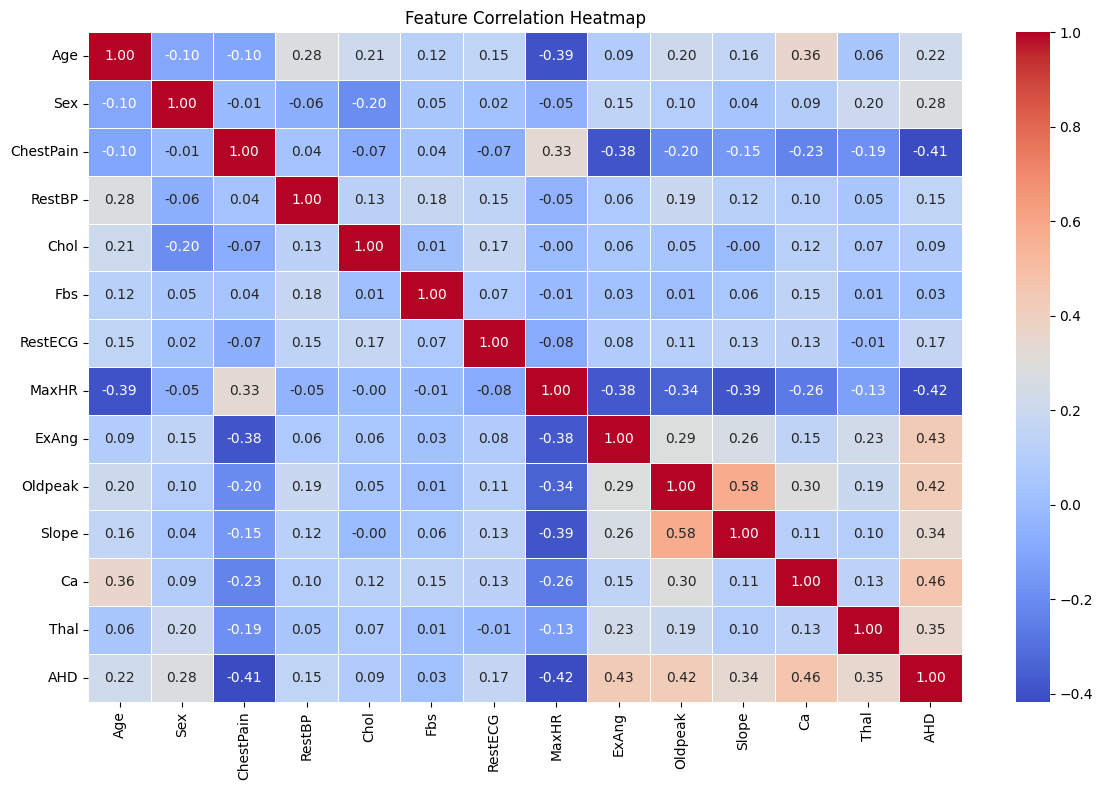

In [8]:
# Cell 8 – EDA: Correlation Heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

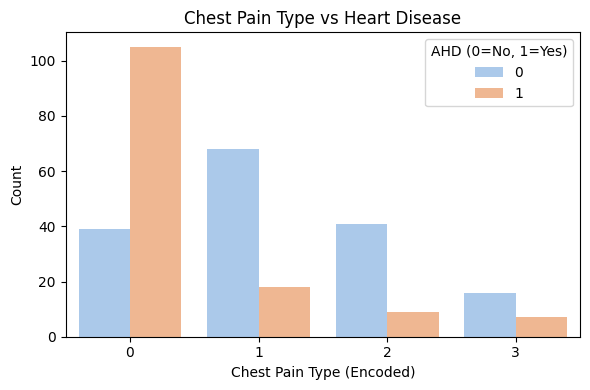

In [9]:
# Cell 9 – EDA: Chest Pain vs Heart Disease

plt.figure(figsize=(6, 4))
sns.countplot(x='ChestPain', hue='AHD', data=df, palette='pastel')
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (Encoded)')
plt.ylabel('Count')
plt.legend(title='AHD (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

In [10]:
# Cell 10 – Prepare Features and Target

X = df.drop(columns=['AHD'])
y = df['AHD']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (303, 13)
Target shape: (303,)

Feature columns: ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal']


In [11]:
# Cell 11 – Train/Test Split and Feature Scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Training samples : {X_train.shape[0]}")
print(f"✅ Testing samples  : {X_test.shape[0]}")

✅ Training samples : 242
✅ Testing samples  : 61


In [13]:
# Cell 12 – Train Logistic Regression Model (Fixed)

# Safety: fill any remaining NaNs in scaled arrays
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled  = np.nan_to_num(X_test_scaled)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f"✅ Logistic Regression Accuracy: {lr_acc * 100:.2f}%")

✅ Logistic Regression Accuracy: 86.89%


In [14]:
# Cell 13 – Train Decision Tree Model

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)

dt_preds = dt_model.predict(X_test_scaled)
dt_acc   = accuracy_score(y_test, dt_preds)

print(f"✅ Decision Tree Accuracy: {dt_acc * 100:.2f}%")

✅ Decision Tree Accuracy: 83.61%


In [15]:
# Cell 14 – Model Comparison

print("=" * 40)
print(f"  Logistic Regression Accuracy : {lr_acc * 100:.2f}%")
print(f"  Decision Tree Accuracy       : {dt_acc * 100:.2f}%")
print("=" * 40)

# Choose the best model
best_model  = lr_model if lr_acc >= dt_acc else dt_model
best_preds  = lr_preds if lr_acc >= dt_acc else dt_preds
best_name   = "Logistic Regression" if lr_acc >= dt_acc else "Decision Tree"
print(f"\n🏆 Best Model Selected: {best_name}")

  Logistic Regression Accuracy : 86.89%
  Decision Tree Accuracy       : 83.61%

🏆 Best Model Selected: Logistic Regression


In [16]:
# Cell 15 – Classification Report

print(f"📋 Classification Report – {best_name}\n")
print(classification_report(y_test, best_preds, target_names=['No Disease', 'Has Disease']))

📋 Classification Report – Logistic Regression

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
 Has Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



<Figure size 600x500 with 0 Axes>

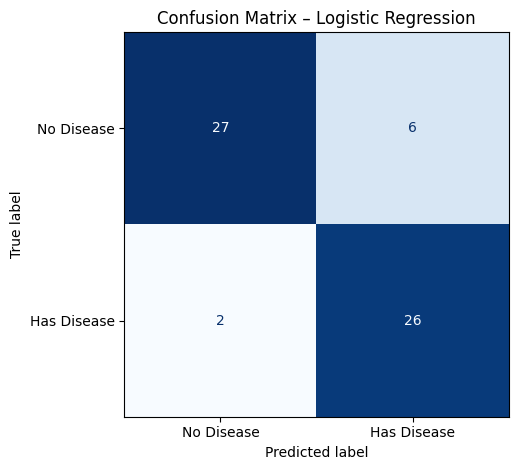

In [17]:
# Cell 16 – Confusion Matrix

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Has Disease'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix – {best_name}')
plt.tight_layout()
plt.show()

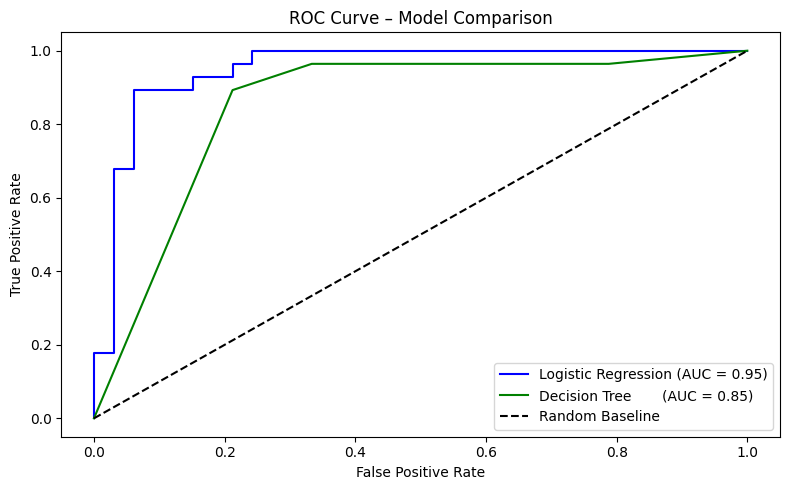


📌 Logistic Regression AUC : 0.9502
📌 Decision Tree AUC       : 0.8539


In [18]:
# Cell 17 – ROC Curve

# Get predicted probabilities
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
dt_probs = dt_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)

lr_auc = roc_auc_score(y_test, lr_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})', color='blue')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree       (AUC = {dt_auc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n📌 Logistic Regression AUC : {lr_auc:.4f}")
print(f"📌 Decision Tree AUC       : {dt_auc:.4f}")

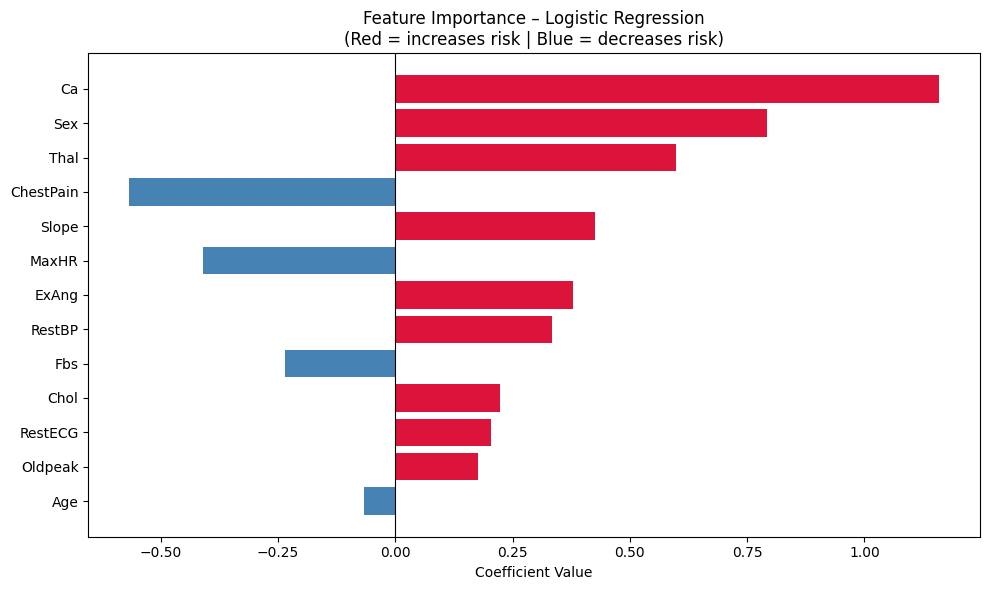


Top Features by Absolute Importance:
  Feature  Coefficient
       Ca     1.159878
      Sex     0.792501
     Thal     0.598421
ChestPain    -0.568065
    Slope     0.425352
    MaxHR    -0.411098
    ExAng     0.379689
   RestBP     0.334250
      Fbs    -0.235903
     Chol     0.223382
  RestECG     0.204750
  Oldpeak     0.176178
      Age    -0.067627


In [19]:
# Cell 18 – Feature Importance (Logistic Regression)

feature_names = X.columns.tolist()
coefficients  = lr_model.coef_[0]

importance_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['crimson' if c > 0 else 'steelblue' for c in importance_df['Coefficient']]
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance – Logistic Regression\n(Red = increases risk | Blue = decreases risk)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop Features by Absolute Importance:")
print(importance_df.to_string(index=False))

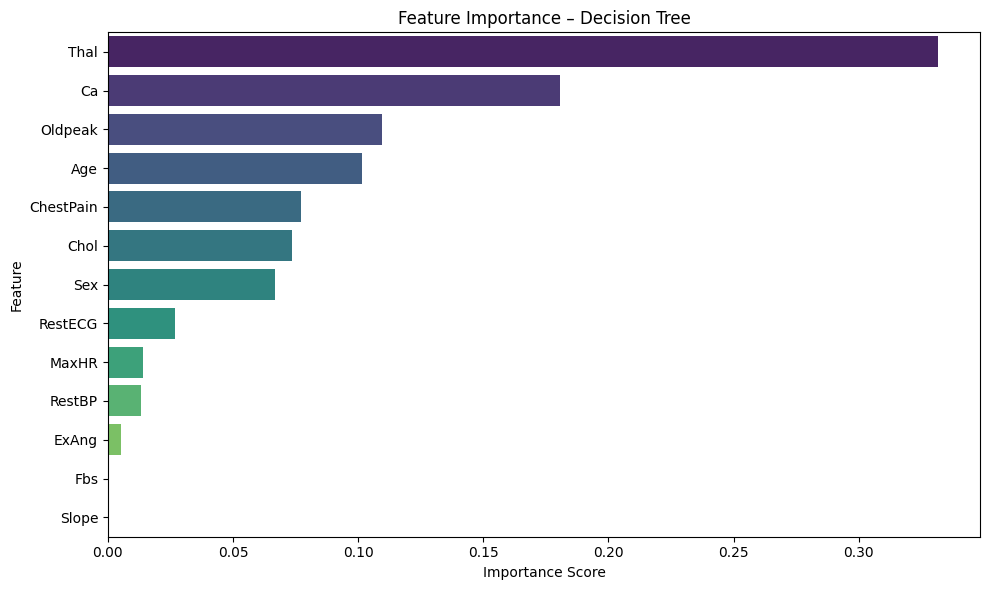


Decision Tree Feature Importance:
  Feature  Importance
     Thal    0.331892
       Ca    0.180467
  Oldpeak    0.109397
      Age    0.101544
ChestPain    0.077265
     Chol    0.073468
      Sex    0.066817
  RestECG    0.026727
    MaxHR    0.013920
   RestBP    0.013363
    ExAng    0.005140
      Fbs    0.000000
    Slope    0.000000


In [20]:
# Cell 19 – Feature Importance (Decision Tree)

dt_importance_df = pd.DataFrame({
    'Feature'  : feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=dt_importance_df, palette='viridis')
plt.title('Feature Importance – Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nDecision Tree Feature Importance:")
print(dt_importance_df.to_string(index=False))

In [21]:
# Cell 20 – Final Summary

print("=" * 55)
print("         ❤️  HEART DISEASE PREDICTION – SUMMARY  ❤️")
print("=" * 55)
print(f"  Dataset Size             : {df.shape[0]} patients, {df.shape[1]} features")
print(f"  Missing Values Handled   : Ca & Thal (filled with mode)")
print(f"  Train / Test Split       : 80% / 20%")
print("-" * 55)
print(f"  Logistic Regression Acc  : {lr_acc * 100:.2f}%  |  AUC: {lr_auc:.4f}")
print(f"  Decision Tree Acc        : {dt_acc * 100:.2f}%  |  AUC: {dt_auc:.4f}")
print("-" * 55)
print(f"  🏆 Best Model            : {best_name}")
print("-" * 55)
print("  Top Predictors (LR):")
for _, row in importance_df.head(5).iterrows():
    direction = "↑ risk" if row['Coefficient'] > 0 else "↓ risk"
    print(f"    • {row['Feature']:<12} : {row['Coefficient']:+.4f}  ({direction})")
print("=" * 55)

         ❤️  HEART DISEASE PREDICTION – SUMMARY  ❤️
  Dataset Size             : 303 patients, 14 features
  Missing Values Handled   : Ca & Thal (filled with mode)
  Train / Test Split       : 80% / 20%
-------------------------------------------------------
  Logistic Regression Acc  : 86.89%  |  AUC: 0.9502
  Decision Tree Acc        : 83.61%  |  AUC: 0.8539
-------------------------------------------------------
  🏆 Best Model            : Logistic Regression
-------------------------------------------------------
  Top Predictors (LR):
    • Ca           : +1.1599  (↑ risk)
    • Sex          : +0.7925  (↑ risk)
    • Thal         : +0.5984  (↑ risk)
    • ChestPain    : -0.5681  (↓ risk)
    • Slope        : +0.4254  (↑ risk)
